## <font color=#0099CC>mIAx - Taller Renta Fija - ANÁLISIS CARTERA DE RENTA FIJA</font>

En esta práctica, desarrollaremos un análisis relativamente exahustivo de un universo de Renta Fija, en concreto, de bonos corporativos. Además, construiremos y analizaremos varias carteras. 

Para ello, contaremos con la siguiente información almacenada en la carpeta *data*:
- Universo de bonos, con sus características esenciales (fichero *universo.csv*)
- Histórico de precios de cierre del universo de bonos anterior (fichero *precios_historicos_universo.csv*)
- Curva de tipos de interés €STR (fichero *curvaESTR.csv*)
- Histórico de precios de otros índices que nos serán de utilidad (fichero *precios_historicos_varios*):
    - Índices de crédito: ITRAXX Main y ITRAXX XOVER. Serán útiles para la cobertura del riesgo de crédito.
    - Futuros sobre el *Schatz* (DU1), *BOBL* (OE1) y *BUND* (RX1). Serán útiles para la cobertura de los tipos de interés.
    - Índice de crédito *RECMTREU*, que valdría como benchmark de las carteras que construyamos.

No necesariamente se usará toda toda la información

En líneas generales, estos son los ejercicios que completaremos, aunque los detallaremos más en cada apartado:
1. Análisis de datos. En esta sección, haremos un análisis de la información que tenemos de cada bono y lo que significa. Asimismo, haremos los tratamientos y limpieza que necesitemos para luego poder usarlos.
2. Valoración de los bonos del universo utilizando la curva de descuento y bajo ciertas asunciones. Comparación de estos precios con los precios de mercado.
3. Cálculo del spread que pagan los bonos sobre la curva.
4. Cálculo de *yield*, duración y convexidad.
5. Contrucción de una cartera equiponderada con todos los bonos del universo. Contraste con el benchmark (os proponemos el índice RECMTREU para el que os hemos dado los precios) y backtest de la estrategia. ¡OJO! El índice es *Total Return*.
6. Tienes el mandato de construir una cartera de como máximo **20** bonos corporativos con ese universo y una serie de restricciones y, claro, maximizando la rentabilidad total de la cartera:
    - La duración de la cartera no debe superar los 3 años
    - La exposición a emisiones HY no puede superar el 10% de la cartera
    - No puedes invertir en deuda subordinada
    - No se puede invertir en emisiones de tamaño igual o inferior a 500 millones
    - No se puede invertir más de un 10% del capital en una misma emisión
    - No puede haber más de un 15% de concentración en un mismo emisor
    (¡OJO! No estamos teniendo en cuenta en este ejercicio si hubiera un mínimo de inversión, lo cuál sería un dato relevante tener en cuenta en un caso real)

    6.1. Constrúyela a fecha de hoy

    6.2. Teniendo en cuenta la naturaleza que nos están pidiendo para la cartera, ¿añadirías alguna otra restricción?

    6.3. ¿Cómo medirías el riesgo de crédito de la cartera?

    6.4. ¿Cómo medirías el riesgo de liquidez de la cartera?

    6.5. Describe cómo habría que hacer el backtest de esta cartera
7. Ahora, se te pide que cubras la exposición de la cartera a los tipos de interés. Con la información que tienes, ¿cómo lo harías?
8. ¿Y si quisieras cubrir total o parcialmente el riesgo de crédito? Usa de nuevo la información que tienes.
9. ¿Cómo construirías tu cartera? ¿Se te ocurre alguna estrategia específica, por ejemplo, de valor relativo?


📣 <font color=#CC6600>**¡NORMAS!**</font>

La práctica se puede hacer en grupos de hasta **3 personas** y deberá entregarse antes del **27 de noviembre**. 

Cada grupo expondrá una parte de los ejercicios en la clase del día 27, donde la resolveremos juntos a modo de taller. Esta exposición contará hasta **1 punto** de la nota final.

Además, se valorará positivamente para la práctica la participación en las clases.

📣 <font color=#CC6600>**¡IMPORTANTE!**</font>

Todo el código implementado debe estar debidamente comentado e incluir conclusiones de los resultados obtenidos para optar a la máxima puntuación. Asimismo, se debe responder a las preguntas planteadas.

Las propuestas de mejora o posibles trabajos futuros se valorarán positivamente también.

Usa las fuentes de información que consideres necesarias para apoyar tus respuestas.

### <font color=#336699>Librerías</font>

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import datetime
import numpy as np

In [4]:
# Estilo
plt.style.use('dark_background')

In [5]:
# Fecha de análisis
fecha_analisis = pd.to_datetime('2025-10-01')

### <font color=#336699>1. Datos</font>

<style>.gray {background-color: #595959}

</style><div class="gray">❕💬¿Qué observas en los datos? Analiza la información que tenemos del universo</div>

Haz un primer análisis visual de la información que tenemos del universo de bono.
Entre otras, plantéate cuestiones como:
- ¿Divisas?
- ¿Tipo de bonos? ¿Fijo/Flotante? ¿Prelación? ¿Opcionalidad? ¿Hay bonos perpetuos?
- ¿Sectores? ¿Emisores? Si invirtéramos en todos los bonos, ¿dirías a priori que la cartera está diversificada?
- ¿Ratings? (Riesgo de crédito)
- ¿Otros datos cuantitativos?
    - Riesgo de liquidez - Horquillas y nominal vivo
- ¿Hay *gaps* en la información que vamos a tener que tratar?

In [6]:
import os
DATA_PATH = "../data"

# Cargar ficheros
universo = pd.read_csv(f"{DATA_PATH}/universo.csv", sep=";")
precios_universo = pd.read_csv(f"{DATA_PATH}/precios_historicos_universo.csv", sep=";")
curva_estr = pd.read_csv(f"{DATA_PATH}/curvaESTR.csv", sep=";")
precios_varios = pd.read_csv(f"{DATA_PATH}/precios_historicos_varios.csv", sep=";")

# ===============================
# Limpieza y formatos
# ===============================

# --- universo: convertir columnas de fechas (NO ffill aquí) ---
date_cols_universo = [
    "Maturity", "First Coupon Date", "Penultimate Coupon Date",
    "Issue date", "Next Call Date"
]
for col in date_cols_universo:
    universo[col] = pd.to_datetime(universo[col], dayfirst=True, errors="coerce")

# Curva ESTR: convertir Date a datetime (sin ffill; ya interpolaremos luego)
curva_estr["Date"] = pd.to_datetime(curva_estr["Date"], dayfirst=True, errors="coerce")

# --- precios_varios: fechas como índice + ffill en el tiempo ---
precios_varios["Date"] = pd.to_datetime(
    precios_varios["Unnamed: 0"], dayfirst=True, errors="coerce"
)
precios_varios = precios_varios.drop(columns=["Unnamed: 0"])
precios_varios = precios_varios.set_index("Date")
precios_varios = precios_varios.sort_index()
precios_varios = precios_varios.ffill()      # rellenamos huecos con último valor conocido

# --- precios_universo: ISIN como índice, columnas = fechas ---
precios_universo["ISIN"] = precios_universo["Unnamed: 0"].str[:12]
precios_universo = precios_universo.drop(columns=["Unnamed: 0"])
precios_universo = precios_universo.set_index("ISIN")

# columnas restantes son fechas
precios_universo.columns = pd.to_datetime(
    precios_universo.columns, dayfirst=True, errors="coerce"
)

# Sustituimos '#N/D' por NaN (datos faltantes) y pasamos a numérico
precios_universo = precios_universo.replace("#N/D", np.nan)
precios_universo = precios_universo.apply(pd.to_numeric, errors="coerce")

# Ordenamos columnas por fecha y hacemos ffill horizontal (en el tiempo)
precios_universo = precios_universo.sort_index(axis=1)
# quitamos columnas completamente vacías, por si acaso
precios_universo = precios_universo.dropna(axis=1, how="all")
# rellenamos huecos con el último precio disponible
precios_universo = precios_universo.ffill(axis=1)

# Fecha de valoración
fecha_valor = datetime.datetime(2025, 10, 1)

print("universo.shape:", universo.shape)
print("precios_universo shape:", precios_universo.shape)
print("curva_estr shape:", curva_estr.shape)
print("precios_varios shape:", precios_varios.shape)


C:\Users\ALBER\AppData\Local\Temp\ipykernel_32220\3343822423.py:6: DtypeWarning: Columns (2,3,4,5,6,9,10,11,12,13,16,17,18,19,20,23,24,25,26,27,30,31,32,33,34,37,38,39,40,41,44,45,46,47,48,51,52,53,54,55,58,59,60,61,62,65,66,67,68,75,89,90,185,219,240,248,275,319,331,415,454,458,473,563,564,565,571,572,573,576,577,578,580,583,604,695) have mixed types. Specify dtype option on import or set low_memory=False.
  precios_universo = pd.read_csv(f"{DATA_PATH}/precios_historicos_universo.csv", sep=";")
C:\Users\ALBER\AppData\Local\Temp\ipykernel_32220\3343822423.py:45: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  precios_universo = precios_universo.replace("#N/D", np.nan)


universo.shape: (2255, 21)
precios_universo shape: (2255, 523)
curva_estr shape: (33, 4)
precios_varios shape: (514, 6)


#### <font color=#808080>Divisas</font>

In [7]:
print("=== Distribución por divisa (Ccy) ===")
dist_divisa = universo["Ccy"].value_counts()
display(dist_divisa.to_frame(name="Número de bonos"))




=== Distribución por divisa (Ccy) ===


,Número de bonos
Ccy,
EUR,2255


#### <font color=#808080>Tipos de bono</font>


=== Distribución por tipo de cupón (Coupon Type) ===


,Número de bonos
Coupon Type,
FIXED,1910
VARIABLE,345


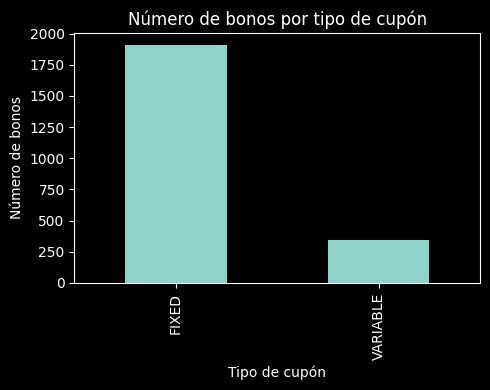


=== Distribución por seniority ===


,Número de bonos
Seniority,
Sr Unsecured,1675
Sr Non Preferred,190
Sr Preferred,179
Subordinated,153
Jr Subordinated,25
Secured,20
1st lien,13


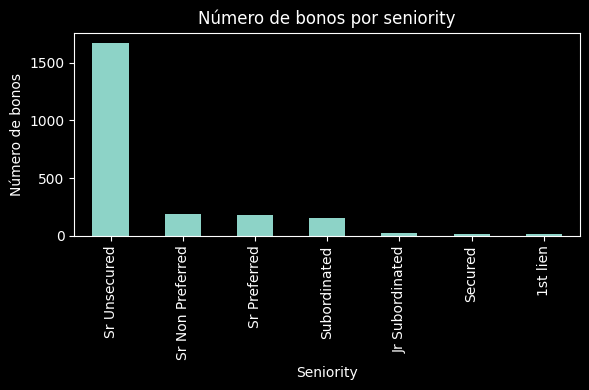

In [8]:
print("\n=== Distribución por tipo de cupón (Coupon Type) ===")
dist_cupon = universo["Coupon Type"].value_counts()
display(dist_cupon.to_frame(name="Número de bonos"))

plt.figure(figsize=(5,4))
dist_cupon.plot(kind="bar")
plt.title("Número de bonos por tipo de cupón")
plt.xlabel("Tipo de cupón")
plt.ylabel("Número de bonos")
plt.tight_layout()
plt.show()

print("\n=== Distribución por seniority ===")
dist_seniority = universo["Seniority"].value_counts()
display(dist_seniority.to_frame(name="Número de bonos"))

plt.figure(figsize=(6,4))
dist_seniority.plot(kind="bar")
plt.title("Número de bonos por seniority")
plt.xlabel("Seniority")
plt.ylabel("Número de bonos")
plt.tight_layout()
plt.show()



#### <font color=#808080>Sectores y emisores</font>


=== Top 10 sectores (Industry Sector) por número de bonos ===


,Número de bonos
Industry Sector,
Financial,1012
"Consumer, Non-cyclical",400
Industrial,211
Communications,175
"Consumer, Cyclical",171
Utilities,150
Basic Materials,72
Technology,51
Energy,13


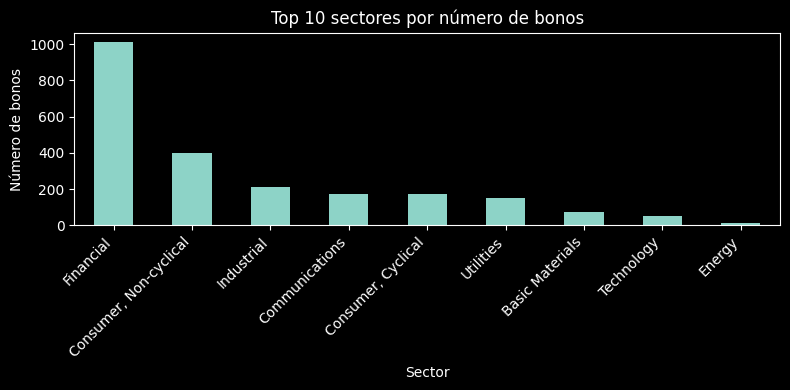


=== Top 10 emisores (Issuer) por número de bonos ===


,Número de bonos
Issuer,
BANQUE FED CRED MUTUEL,33
BNP PARIBAS,27
VONOVIA SE,23
ORANGE SA,23
BPCE SA,23
SOCIETE GENERALE,21
VOLKSWAGEN INTL FIN NV,21
NESTLE FINANCE INTL LTD,20
CREDIT AGRICOLE SA,19


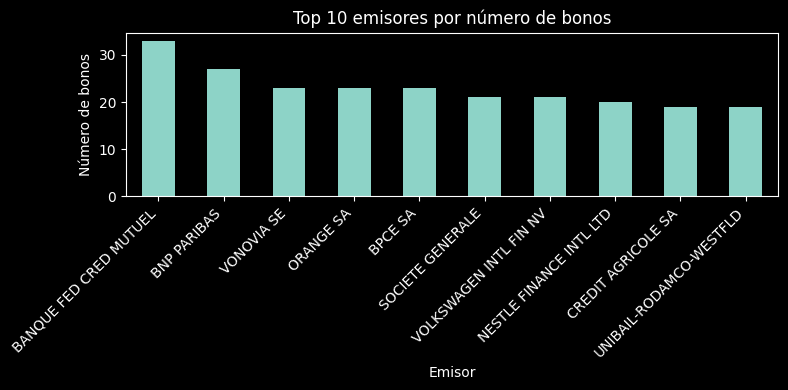

In [9]:
print("\n=== Top 10 sectores (Industry Sector) por número de bonos ===")
dist_sector = universo["Industry Sector"].value_counts().head(10)
display(dist_sector.to_frame(name="Número de bonos"))

plt.figure(figsize=(8,4))
dist_sector.plot(kind="bar")
plt.title("Top 10 sectores por número de bonos")
plt.xlabel("Sector")
plt.ylabel("Número de bonos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\n=== Top 10 emisores (Issuer) por número de bonos ===")
dist_issuer = universo["Issuer"].value_counts().head(10)
display(dist_issuer.to_frame(name="Número de bonos"))

plt.figure(figsize=(8,4))
dist_issuer.plot(kind="bar")
plt.title("Top 10 emisores por número de bonos")
plt.xlabel("Emisor")
plt.ylabel("Número de bonos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### <font color=#808080>Ratings (Riesgo de crédito)</font>


=== Distribución por rating ===


,Número de bonos
Rating,
BBB+,439
NR,389
A-,374
BBB,310
A,230
A+,185
BBB-,184
AA-,100
AA,22


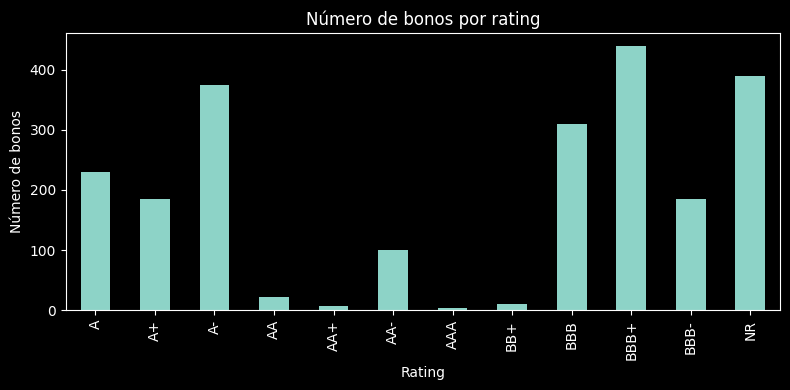

In [10]:
print("\n=== Distribución por rating ===")
dist_rating = universo["Rating"].value_counts()
display(dist_rating.to_frame(name="Número de bonos"))

plt.figure(figsize=(8,4))
dist_rating.sort_index().plot(kind="bar")
plt.title("Número de bonos por rating")
plt.xlabel("Rating")
plt.ylabel("Número de bonos")
plt.tight_layout()
plt.show()

#### <font color=#808080>Riesgo de liquidez - Horquillas y nominal vivo</font>

=== Estadísticos del Bid-Ask Spread ===


,Bid-Ask Spread
count,2255.000000
mean,0.327213
std,0.165488
min,0.064000
25%,0.201000
50%,0.294000
75%,0.418000
max,2.255000


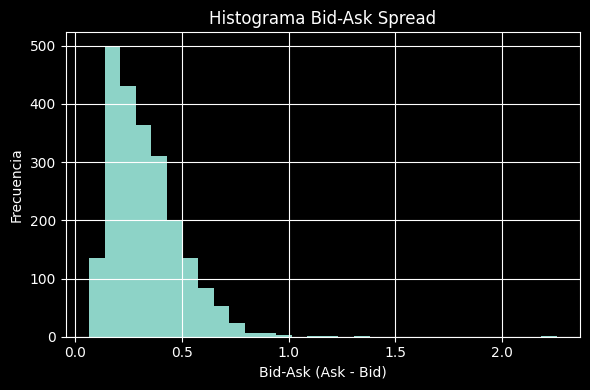


=== Estadísticos del Outstanding Amount ===


,Outstanding Amount
count,2.255000e+03
mean,7.449289e+08
std,3.095138e+08
min,2.499970e+08
25%,5.000000e+08
50%,7.000000e+08
75%,1.000000e+09
max,3.000000e+09


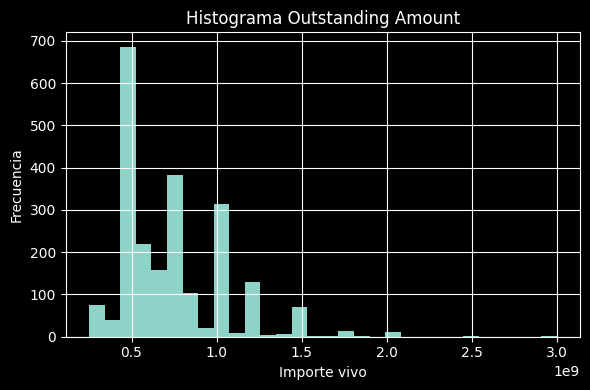

In [11]:
# Horquilla bid-ask
universo["Bid-Ask Spread"] = universo["Ask Price"] - universo["Bid Price"]

print("=== Estadísticos del Bid-Ask Spread ===")
display(universo["Bid-Ask Spread"].describe().to_frame(name="Bid-Ask Spread"))

plt.figure(figsize=(6,4))
universo["Bid-Ask Spread"].hist(bins=30)
plt.title("Histograma Bid-Ask Spread")
plt.xlabel("Bid-Ask (Ask - Bid)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print("\n=== Estadísticos del Outstanding Amount ===")
display(universo["Outstanding Amount"].describe().to_frame(name="Outstanding Amount"))

plt.figure(figsize=(6,4))
universo["Outstanding Amount"].hist(bins=30)
plt.title("Histograma Outstanding Amount")
plt.xlabel("Importe vivo")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()



#### <font color=#808080>Resto de información</font>

En esta sección, analizamos el resto de ficheros para ver qué información tenemos y, en caso de haber *gaps*, limpiar los datos antes de trabajar con ellos.

##### <font color=#CC6600>Precios bonos universo</font>


=== Porcentaje de NaNs por bono (estadísticos) ===


,% NaNs
count,2255.000000
mean,0.002231
std,0.011870
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,0.093690



Proporción de bonos con más del 20% de huecos en precios: 0.00%


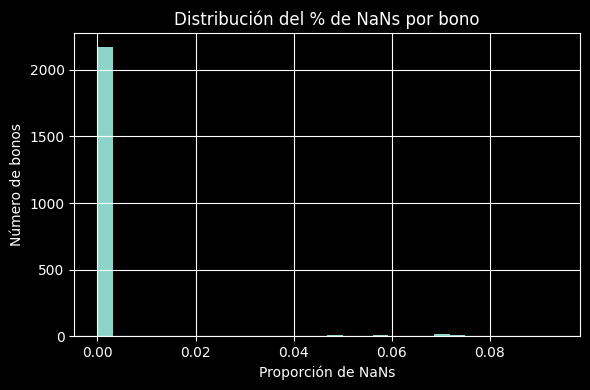

In [12]:
# Calidad del histórico de precios (NaNs)
panel_precios = precios_universo.copy()
panel_precios = panel_precios.replace("#N/D", np.nan)
panel_precios = panel_precios.apply(pd.to_numeric, errors="coerce")

# % de huecos por bono (fila = bono, columnas = fechas)
na_pct_por_bono = panel_precios.isna().mean(axis=1)

print("\n=== Porcentaje de NaNs por bono (estadísticos) ===")
display(na_pct_por_bono.describe().to_frame(name="% NaNs"))

prop_mas_20 = (na_pct_por_bono > 0.2).mean()
print(f"\nProporción de bonos con más del 20% de huecos en precios: {prop_mas_20:.2%}")

plt.figure(figsize=(6,4))
na_pct_por_bono.hist(bins=30)
plt.title("Distribución del % de NaNs por bono")
plt.xlabel("Proporción de NaNs")
plt.ylabel("Número de bonos")
plt.tight_layout()
plt.show()

##### <font color=#CC6600>Otros precios</font>

Para terminar con el análisis de datos, falta lo leído en los ficheros de *"precios_historicos_varios.csv"* y *curvaESTR.csv*.

Vista previa de precios_historicos_varios:


,ITRX EUR CDSI GEN 5Y Corp,ITRX XOVER CDSI GEN 5Y Corp,DU1 Comdty,OE1 Comdty,RX1 Comdty,RECMTREU Index
Date,,,,,,
2023-10-02,82.44325,439.1052,104.93,115.43,127.75,149.0285
2023-10-03,86.04738,455.2537,104.965,115.33,127.28,148.8003
2023-10-04,85.58153,453.8545,104.99,115.35,127.37,148.5200
2023-10-05,87.82574,461.1187,105.095,115.73,128.07,148.8967
2023-10-06,85.57082,453.675,105.105,115.72,127.94,148.7697



Porcentaje de valores nulos por columna en precios_varios:


ITRX EUR CDSI GEN 5Y Corp      0.0
ITRX XOVER CDSI GEN 5Y Corp    0.0
DU1 Comdty                     0.0
OE1 Comdty                     0.0
RX1 Comdty                     0.0
RECMTREU Index                 0.0
dtype: float64


Vista previa de la curva €STR:


,Date,Market Rate,Zero Rate,Discount
0,2025-10-01,NaN,NaN,1.000000
1,2025-10-10,1.927,1.95350,0.999518
2,2025-10-17,1.928,1.95402,0.999144
3,2025-11-03,1.928,1.95320,0.998236
4,2025-12-03,1.929,1.95264,0.996635



Porcentaje de valores nulos en curva €STR:


Date           0.000000
Market Rate    0.030303
Zero Rate      0.030303
Discount       0.000000
dtype: float64

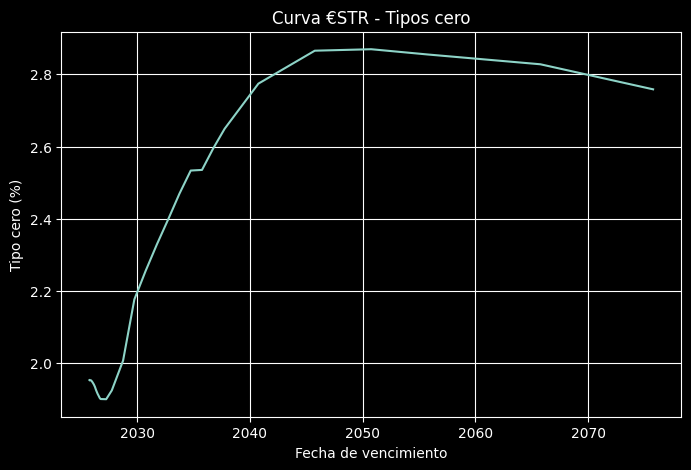

In [13]:
print("Vista previa de precios_historicos_varios:")
display(precios_varios.head())

print("\nPorcentaje de valores nulos por columna en precios_varios:")
display(precios_varios.isna().mean())


print("\nVista previa de la curva €STR:")
display(curva_estr.head())

print("\nPorcentaje de valores nulos en curva €STR:")
display(curva_estr.isna().mean())

# Representación gráfica de la curva €STR
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(curva_estr["Date"], curva_estr["Zero Rate"])
plt.title("Curva €STR - Tipos cero")
plt.xlabel("Fecha de vencimiento")
plt.ylabel("Tipo cero (%)")
plt.grid(True)
plt.show()


### <font color=#336699>2. Valoración</font>

<style>.gray {background-color: #595959}

</style><div class="gray">

❕💬 En esta sección, valoraremos los bonos utilizando la curva. Para ello, crea una función (puedes hacerlo en un .py aparte) que con las **características del bono, la curva y un spread de crédito** devuelva la valoración del bono (incluyendo **precio limpio, cupón corrido y precio sucio**).

Si asumimos que el **spread de crédito es 0**, y la ejecutamos para el 01/10/2025...
- ¿Qué observas si comparas los precios obtenidos y los precios de mercado? 
- ¿Crees que la diferencia se debe a un factor relacionado sólo con el riesgo crediticio?
- ¿Qué otros factores influyen en ese spread?

Para la valoración, haz las siguientes simplificaciones:

- Asume que el vencimiento de los bonos perpetuos (para los que no hay vencimiento) es la próxima fecha call.
- Asume que todos aquellos bonos que tengan call serán calleados. Por lo tanto, usa la fecha call como fecha de vencimiento.
- Asume que los cupones son fijos hasta vencimiento (aunque alguno cambie a lo largo de la vida del bono).
- Usa la base de cálculo ACT/365. No tengas en cuenta la convención de día hábil.

Ten en cuenta que necesitarás una función de interpolación también. Interpola los factores de descuento exponencialmente.

</div>

In [14]:
# Establecemos la fecha
fecha_valor = datetime.datetime(2025,10,1)

Ejemplo de comparación modelo vs mercado (primeros bonos):


,ISIN,Price,Precio_modelo_clean,Diff_price_clean
0,XS0161488498,127.8353,133.757847,-5.922547
1,FR0000471930,131.3195,137.971025,-6.651525
2,XS0162513211,115.7800,122.217546,-6.437546
3,XS0162869076,116.3000,123.056925,-6.756925
4,FR0010014845,112.3887,125.363091,-12.974391



Estadísticos de la diferencia mercado - modelo (precio limpio):


,Market - Modelo
count,2255.000000
mean,-3.615749
std,3.211500
min,-23.465678
25%,-4.680096
50%,-2.632591
75%,-1.431435
max,-0.219632


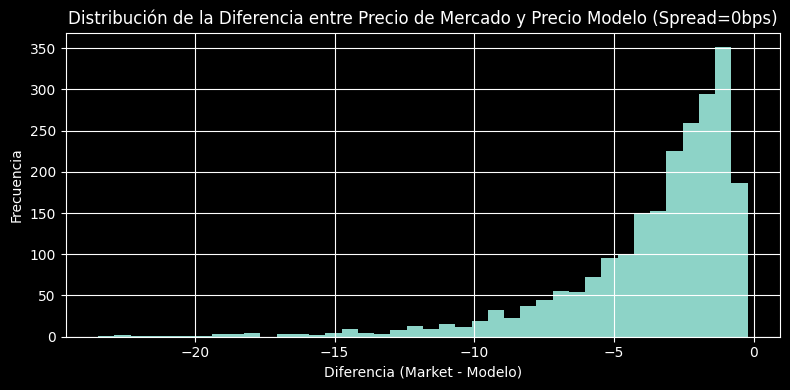

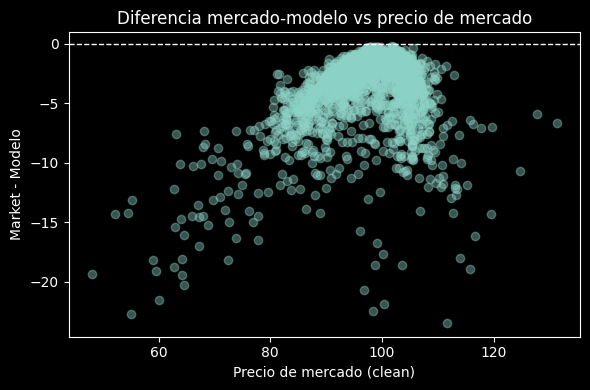

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# 2. Curva €STR y descuento de flujos
# ===============================

# Aseguramos que la fecha de la curva está en formato datetime (por si acaso)
curva_estr["Date"] = pd.to_datetime(curva_estr["Date"], dayfirst=True, errors="coerce")

# --- 2.1 Fracción de año ACT/365 ---
def year_frac(d):
    return (d - fecha_valor).days / 365.0

# Ordenamos la curva por fecha y calculamos t (años)
curva_estr_ord = curva_estr.sort_values("Date").copy()
curva_estr_ord["t"] = curva_estr_ord["Date"].apply(year_frac)
curva_estr_ord = curva_estr_ord[curva_estr_ord["t"] >= 0]

# ⚠️ Usamos la columna 'Discount' como factores de descuento de mercado
curva_estr_ord = curva_estr_ord.dropna(subset=["Discount"])

t_curva = curva_estr_ord["t"].values                       # plazos en años
df_curva = curva_estr_ord["Discount"].astype(float).values # factores DF
ln_df_curva = np.log(df_curva)                             # ln(DF)

def discount_factor(fecha_pago):
    """
    Factor de descuento DF(t) usando interpolación exponencial
    sobre los factores Discount de la curva €STR.
    """
    t = year_frac(fecha_pago)
    if t <= 0:
        return 1.0
    ln_df = np.interp(t, t_curva, ln_df_curva)
    return float(np.exp(ln_df))


# ===============================
# 2.2 Vencimiento efectivo (Maturity_efectiva) con CALL
# ===============================

def get_maturity_efectiva(row):
    """
    - Si Callable = 'Y' y hay Next Call Date -> usamos esa fecha como
      vencimiento efectivo.
    - En el resto de casos usamos Maturity normal.
    """
    maturity = row.get("Maturity", pd.NaT)
    call_date = row.get("Next Call Date", pd.NaT)
    callable_flag = str(row.get("Callable", "")).strip().upper()

    if callable_flag == "Y" and not pd.isna(call_date):
        return call_date

    return maturity

# Añadimos la columna de Maturity efectivo al universo
universo["Maturity_efectiva"] = universo.apply(get_maturity_efectiva, axis=1)


# ===============================
# 2.3 Generar calendario de cupones de un bono
# ===============================

def generar_fechas_cupon(row):
    """
    Devuelve las fechas de pago de cupón (desde el primer cupón hasta el
    vencimiento efectivo). Luego filtraremos por flujos futuros.
    """
    maturity = row["Maturity_efectiva"]
    first = row["First Coupon Date"]
    freq = row["Coupon Frequency"]

    if pd.isna(maturity) or pd.isna(first) or pd.isna(freq):
        return []

    freq = int(freq)
    if freq <= 0:
        return []

    meses = 12 // freq
    fechas = []
    f = first

    while f <= maturity + pd.Timedelta(days=7):
        fechas.append(f)
        f = f + pd.DateOffset(months=meses)

    if maturity not in fechas:
        fechas.append(maturity)

    fechas = sorted(pd.to_datetime(fechas))
    return fechas


# ===============================
# 2.4 Valorar un bono: precio limpio, cupón corrido, precio sucio
# ===============================

def valorar_bono(row, spread_bps=0.0, nominal=100.0):
    """
    Valora un bono con:
      - curva €STR (libre de riesgo) → discount_factor()
      - spread de crédito plano en bps (sumado sobre la curva)
    Devuelve:
      - precio limpio (% del nominal)
      - cupón corrido (% del nominal)
      - precio sucio (% del nominal)
    """
    maturity = row["Maturity_efectiva"]
    coupon_rate = row["Coupon"] / 100.0
    freq = row["Coupon Frequency"]

    if pd.isna(maturity) or pd.isna(coupon_rate) or pd.isna(freq):
        return np.nan, np.nan, np.nan

    freq = int(freq)
    fechas_todas = generar_fechas_cupon(row)
    if len(fechas_todas) == 0:
        return np.nan, np.nan, np.nan

    # Spread de crédito en tanto (100 bps = 1% = 0.01)
    s = spread_bps / 10000.0

    # 1) Valor presente de flujos futuros (cupones + principal en el último)
    pv = 0.0
    last_coupon_before_val = None

    for i, d in enumerate(fechas_todas):
        if d <= fecha_valor:
            last_coupon_before_val = d
            continue

        # Suponemos cupones "regulares": cupón / freq
        cf = coupon_rate * nominal / freq
        if i == len(fechas_todas) - 1:
            cf += nominal

        df_rf = discount_factor(d)
        t = year_frac(d)
        df_total = df_rf * np.exp(-s * t)
        pv += cf * df_total

    # 2) Cupón corrido (aprox ACT/365 entre último cupón y fecha_valor)
    if last_coupon_before_val is not None:
        futuros = [d for d in fechas_todas if d > fecha_valor]
        next_coupon = min(futuros) if futuros else None

        if next_coupon is not None:
            days_total = (next_coupon - last_coupon_before_val).days
            days_passed = (fecha_valor - last_coupon_before_val).days
            accrual_factor = days_passed / days_total
            coupon_period_nominal = coupon_rate * nominal / freq
            accrued = accrual_factor * coupon_period_nominal
        else:
            accrued = 0.0
    else:
        accrued = 0.0

    dirty_price = pv / nominal * 100.0
    clean_price = dirty_price - accrued / nominal * 100.0

    return clean_price, accrued / nominal * 100.0, dirty_price


# ===============================
# 2.5 Aplicar la valoración (spread = 0) a los bonos vivos
# ===============================

# Bonos "vivos" usando la Maturity efectiva
vivos = universo[universo["Maturity_efectiva"] > fecha_valor].copy()

res_val = vivos.apply(
    lambda r: pd.Series(
        valorar_bono(r, spread_bps=0.0),
        index=["Precio_modelo_clean", "Cupon_corrido_pct", "Precio_modelo_dirty"]
    ),
    axis=1
)

vivos = vivos.join(res_val)

# Sólo bonos con precio de mercado y precio modelo válidos
vivos_validos = vivos.dropna(subset=["Precio_modelo_clean", "Price"]).copy()

# Diferencia precio de mercado (limpio) - precio modelo (limpio)
vivos_validos["Diff_price_clean"] = (
    vivos_validos["Price"] - vivos_validos["Precio_modelo_clean"]
)

print("Ejemplo de comparación modelo vs mercado (primeros bonos):")
display(
    vivos_validos[["ISIN", "Price", "Precio_modelo_clean", "Diff_price_clean"]]
    .head()
)

print("\nEstadísticos de la diferencia mercado - modelo (precio limpio):")
display(vivos_validos["Diff_price_clean"].describe().to_frame("Market - Modelo"))

# Histograma de la diferencia mercado - modelo
plt.figure(figsize=(8,4))
vivos_validos["Diff_price_clean"].hist(bins=40)
plt.title("Distribución de la Diferencia entre Precio de Mercado y Precio Modelo (Spread=0bps)")
plt.xlabel("Diferencia (Market - Modelo)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Scatter: Precio mercado vs diferencia
plt.figure(figsize=(6,4))
plt.scatter(vivos_validos["Price"], vivos_validos["Diff_price_clean"], alpha=0.4)
plt.title("Diferencia mercado-modelo vs precio de mercado")
plt.xlabel("Precio de mercado (clean)")
plt.ylabel("Market - Modelo")
plt.axhline(0, color="white", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()


### <font color=#336699>3. Spread</font>

<style>.gray {background-color: #595959}

</style><div class="gray">

❕💬 Calculemos ahora los spreads que debemos añadir a la curva con un movimiento paralelo para que cuadren los precios de mercado que tenemos. Para ello, usa la función de valoración del apartado anterior. 
- ¿Qué observas? ¿Tienen sentido los resultados? 
- ¿Con qué datos de los que tenemos compararías para ver si los resultados son coherentes?

</div>

Calculando Z-spreads... (puede tardar unos segundos)


,ISIN,Price,Precio_modelo_clean,Z_spread_bps
0,XS0161488498,127.8353,133.757847,74.378485
1,FR0000471930,131.3195,137.971025,81.904379
2,XS0162513211,115.7800,122.217546,85.550665
3,XS0162869076,116.3000,123.056925,89.516733
4,FR0010014845,112.3887,125.363091,163.401057



Estadísticos del Z-spread (bps):


,Z-spread (bps)
count,2255.000000
mean,88.289343
std,49.536653
min,8.988384
25%,65.170695
50%,84.047130
75%,104.549680
max,1735.224700


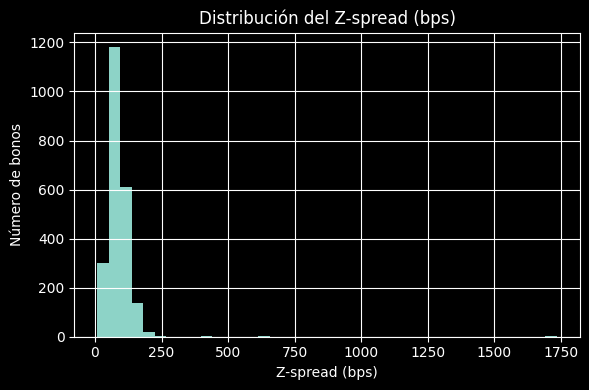

<Figure size 800x500 with 0 Axes>

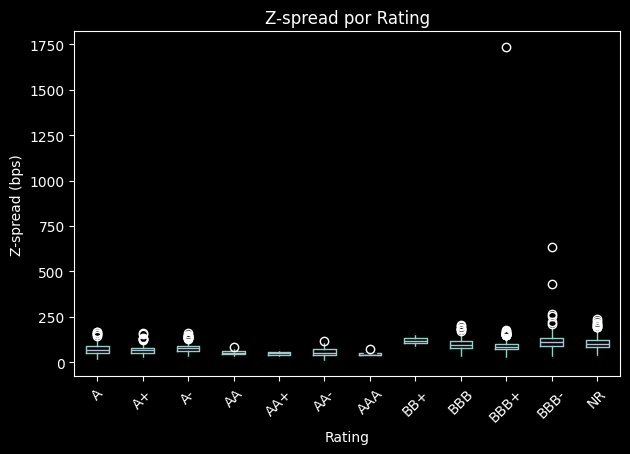

In [16]:
# ===============================
# 3. Cálculo del Z-spread plano
# ===============================

from numpy import sign

def encontrar_zspread(row, nominal=100.0):
    """
    Encuentra el spread plano (en bps) que iguala el precio modelo (dirty)
    con el precio de mercado (dirty).
    Usa bisección numérica.
    """

    # Precio sucio de mercado = precio limpio + cupón corrido modelo
    precio_limpio = row["Price"]
    _, cupon_corr, _ = valorar_bono(row, spread_bps=0.0)
    precio_sucio_mercado = precio_limpio + cupon_corr

    # Función objetivo: diferencia entre precio modelo y mercado
    def f(spread_bps):
        _, _, precio_sucio_modelo = valorar_bono(row, spread_bps=spread_bps)
        return precio_sucio_modelo - precio_sucio_mercado

    # Intervalo razonable de búsqueda en bps
    a, b = -500, 2000

    # Bisección
    for _ in range(50):
        m = (a + b) / 2
        if sign(f(a)) == sign(f(m)):
            a = m
        else:
            b = m

    return m


print("Calculando Z-spreads... (puede tardar unos segundos)")
vivos["Z_spread_bps"] = vivos.apply(encontrar_zspread, axis=1)

display(vivos[["ISIN", "Price", "Precio_modelo_clean", "Z_spread_bps"]].head())


# ===============================
# Estadísticos del Z-spread
# ===============================

print("\nEstadísticos del Z-spread (bps):")
display(vivos["Z_spread_bps"].describe().to_frame("Z-spread (bps)"))


# ===============================
# Visualización
# ===============================

plt.figure(figsize=(6,4))
vivos["Z_spread_bps"].hist(bins=40)
plt.title("Distribución del Z-spread (bps)")
plt.xlabel("Z-spread (bps)")
plt.ylabel("Número de bonos")
plt.tight_layout()
plt.show()

# Relación rating - Z-spread
plt.figure(figsize=(8,5))
vivos.boxplot(column="Z_spread_bps", by="Rating", grid=False, rot=45)
plt.title("Z-spread por Rating")
plt.suptitle("")
plt.xlabel("Rating")
plt.ylabel("Z-spread (bps)")
plt.tight_layout()
plt.show()


In [17]:
# ===============================
# Media de Z-spread por Rating
# ===============================

zspread_por_rating = (
    vivos
    .dropna(subset=["Z_spread_bps", "Rating"])
    .groupby("Rating")["Z_spread_bps"]
    .mean()
    .sort_values()
)

print("\nMedia del Z-spread por Rating (bps):")
display(zspread_por_rating.to_frame("Z-spread medio (bps)"))



Media del Z-spread por Rating (bps):


,Z-spread medio (bps)
Rating,
AAA,48.075613
AA+,48.266831
AA,51.022922
AA-,53.576202
A+,66.400577
A,70.628084
A-,78.320052
BBB+,90.382765
BBB,99.590191


### <font color=#336699>4. YTM, Duración, Convexidad</font>

<style>.gray {background-color: #595959}

</style><div class="gray">

❕💬 Calculemos ahora la siguiente información, también relacionada con la rentabilidad y riesgo de las emisiones:
- *Yield* - Por simplicidad, en este caso, en el caso de los bonos callable, nos quedaremos con la fecha call, como en el ejercicio anterior. Usa las mismas asunciones que para la valoración y el spread.
- Duración
- Convexidad

Responde a las siguientes preguntas:
- ¿Que relación hay entre la TIR calculada y el spread calculado en el apartado anterior?
- ¿Qué relación hay entre la duración y el vencimiento? ¿Qué refleja la duración? ¿De qué otra forma se podría obtener esta sensibilidad?
- Estima el precio del bono usando la duración y convexidad, ¿qué observas?

</div>

Calculando YTM (puede tardar unos segundos)...
Ejemplo de YTM vs Z-spread:


,ISIN,Price,YTM,Z_spread_bps
0,XS0161488498,127.8353,0.038699,74.378485
1,FR0000471930,131.3195,0.039800,81.904379
2,XS0162513211,115.7800,0.038177,85.550665
3,XS0162869076,116.3000,0.038687,89.516733
4,FR0010014845,112.3887,0.041667,163.401057



Estadísticos del YTM:


,YTM (tanto)
count,2254.000000
mean,0.035025
std,0.007479
min,0.021543
25%,0.030305
50%,0.033891
75%,0.037995
max,0.115180



Calculando duración y convexidad...
Ejemplo de YTM, duración y convexidad:


,ISIN,YTM,Z_spread_bps,Duration_mod,Convexity
0,XS0161488498,0.038699,74.378485,5.594910,41.734633
1,FR0000471930,0.039800,81.904379,5.524514,41.017967
2,XS0162513211,0.038177,85.550665,5.877569,44.751906
3,XS0162869076,0.038687,89.516733,5.854974,44.507753
4,FR0010014845,0.041667,163.401057,6.378319,51.453179


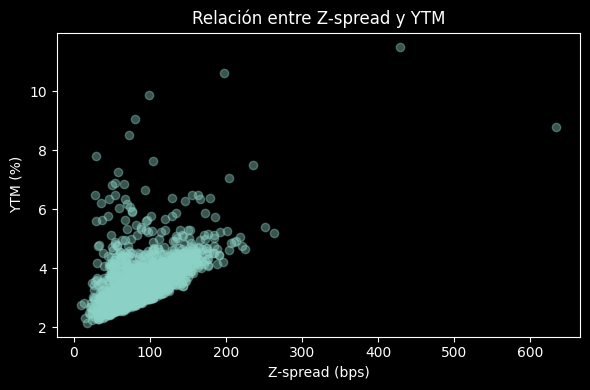

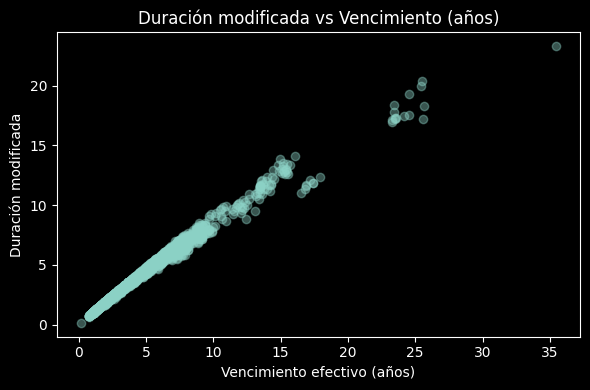


Ejemplo para estimar el cambio de precio con duración y convexidad:
ISIN: XS0161488498
Precio actual (clean): 127.8353
YTM actual: 3.87%
Duración modificada: 5.5949
Convexidad: 41.7346

Movimiento simulado: +100 bps en spread
Precio aproximado con duración+convexidad: 120.9498
Cambio aprox (%): -5.39%
Cambio 'real' modelo (%): -5.65%


In [18]:
# ===============================
# 4. Yield (TIR), Duración y Convexidad
# ===============================

# 4.1 Cálculo del Yield to Maturity (YTM / TIR del bono)
def calcular_ytm(row, nominal=100.0):
    """
    Calcula el YTM (TIR) del bono usando:
      - Maturity_efectiva
      - cupones fijos
      - ACT/365
    Se iguala el precio limpio de mercado a la suma de flujos descontados
    a un tipo constante y.
    """
    maturity = row["Maturity_efectiva"]
    coupon = row["Coupon"] / 100.0
    freq = row["Coupon Frequency"]

    if pd.isna(maturity) or pd.isna(coupon) or pd.isna(freq):
        return np.nan

    freq = int(freq)
    fechas = generar_fechas_cupon(row)
    if len(fechas) == 0:
        return np.nan

    # Construimos flujos futuros
    cfs = []
    ts = []
    for f in fechas:
        t = year_frac(f)  # ACT/365
        if t <= 0:
            continue
        cf = coupon * nominal / freq
        if f == maturity:
            cf += nominal
        cfs.append(cf)
        ts.append(t)

    if len(cfs) == 0:
        return np.nan

    # Precio limpio de mercado en nominal
    market_price = row["Price"] / 100.0 * nominal

    # Función objetivo: PV(y) - precio_mercado = 0
    def g(y):
        pv = 0.0
        for cf, t in zip(cfs, ts):
            pv += cf / (1 + y / freq) ** (freq * t)
        return pv - market_price

    # Búsqueda por bisección en un rango razonable [-5%, 20%]
    lo, hi = -0.05, 0.20
    g_lo, g_hi = g(lo), g(hi)

    # Si no hay cambio de signo o NaNs, devolvemos NaN
    if np.isnan(g_lo) or np.isnan(g_hi) or g_lo * g_hi > 0:
        return np.nan

    for _ in range(50):
        mid = (lo + hi) / 2
        g_mid = g(mid)
        if np.isnan(g_mid):
            return np.nan
        if g_lo * g_mid <= 0:
            hi = mid
            g_hi = g_mid
        else:
            lo = mid
            g_lo = g_mid

    return mid  # YTM en tanto (p.ej. 0.03 = 3%)


print("Calculando YTM (puede tardar unos segundos)...")
vivos["YTM"] = vivos.apply(calcular_ytm, axis=1)

print("Ejemplo de YTM vs Z-spread:")
display(vivos[["ISIN", "Price", "YTM", "Z_spread_bps"]].head())

print("\nEstadísticos del YTM:")
display(vivos["YTM"].describe().to_frame("YTM (tanto)"))


# ===============================
# 4.2 Duración y Convexidad
# ===============================

def calcular_duracion_convexidad(row, nominal=100.0):
    """
    Calcula:
      - Duración modificada
      - Convexidad
    usando el YTM calculado previamente.
    """
    y = row["YTM"]
    if pd.isna(y):
        return np.nan, np.nan

    maturity = row["Maturity_efectiva"]
    coupon = row["Coupon"] / 100.0
    freq = row["Coupon Frequency"]

    if pd.isna(maturity) or pd.isna(coupon) or pd.isna(freq):
        return np.nan, np.nan

    freq = int(freq)
    fechas = generar_fechas_cupon(row)
    if len(fechas) == 0:
        return np.nan, np.nan

    cfs = []
    ts = []
    for f in fechas:
        t = year_frac(f)
        if t <= 0:
            continue
        cf = coupon * nominal / freq
        if f == maturity:
            cf += nominal
        cfs.append(cf)
        ts.append(t)

    if len(cfs) == 0:
        return np.nan, np.nan

    # Precio con el YTM
    pv = sum(cf / (1 + y / freq) ** (freq * t) for cf, t in zip(cfs, ts))

    # Duración de Macaulay
    num = sum(t * cf / (1 + y / freq) ** (freq * t) for cf, t in zip(cfs, ts))
    dur_mac = num / pv

    # Duración modificada
    dur_mod = dur_mac / (1 + y / freq)

    # Convexidad (aprox estándar)
    conv = sum(
        cf * t * (t + 1 / freq) / (1 + y / freq) ** (freq * t + 2)
        for cf, t in zip(cfs, ts)
    ) / pv

    return dur_mod, conv

print("\nCalculando duración y convexidad...")
dur_conv = vivos.apply(
    lambda r: pd.Series(
        calcular_duracion_convexidad(r),
        index=["Duration_mod", "Convexity"]
    ),
    axis=1
)

vivos = vivos.join(dur_conv)

print("Ejemplo de YTM, duración y convexidad:")
display(vivos[["ISIN", "YTM", "Z_spread_bps", "Duration_mod", "Convexity"]].head())


# ===============================
# 4.3 Visualizaciones para interpretar relaciones
# ===============================

# Relación YTM - Z-spread
plt.figure(figsize=(6,4))
plt.scatter(vivos["Z_spread_bps"], vivos["YTM"] * 100, alpha=0.4)
plt.title("Relación entre Z-spread y YTM")
plt.xlabel("Z-spread (bps)")
plt.ylabel("YTM (%)")
plt.tight_layout()
plt.show()

# Relación Duración - Vencimiento
vivos["T_maturity_anos"] = (vivos["Maturity_efectiva"] - fecha_valor).dt.days / 365.0

plt.figure(figsize=(6,4))
plt.scatter(vivos["T_maturity_anos"], vivos["Duration_mod"], alpha=0.4)
plt.title("Duración modificada vs Vencimiento (años)")
plt.xlabel("Vencimiento efectivo (años)")
plt.ylabel("Duración modificada")
plt.tight_layout()
plt.show()


# ===============================
# 4.4 Estimación de precio usando duración y convexidad (ejemplo)
# ===============================

# Elegimos un bono de ejemplo (el primero con datos completos)
ejemplo = vivos.dropna(subset=["YTM", "Duration_mod", "Convexity"]).iloc[0]

print("\nEjemplo para estimar el cambio de precio con duración y convexidad:")
print("ISIN:", ejemplo["ISIN"])
print(f"Precio actual (clean): {ejemplo['Price']:.4f}")
print(f"YTM actual: {ejemplo['YTM']*100:.2f}%")
print(f"Duración modificada: {ejemplo['Duration_mod']:.4f}")
print(f"Convexidad: {ejemplo['Convexity']:.4f}")

# Supongamos un movimiento paralelo de +100 bps en el rendimiento (1%)
dy = 0.01  # 1%

# Aproximación con duración+convexidad:
dP_P_aprox = -ejemplo["Duration_mod"] * dy + 0.5 * ejemplo["Convexity"] * dy**2
precio_aprox = ejemplo["Price"] * (1 + dP_P_aprox)

# Para comparar, usamos la función de valoración cambiando el spread en +100 bps
spread_actual = ejemplo["Z_spread_bps"]
_, _, dirty_antes = valorar_bono(ejemplo, spread_bps=spread_actual)
_, _, dirty_despues = valorar_bono(ejemplo, spread_bps=spread_actual + 100)

precio_modelo_antes = dirty_antes  # % nominal, aprox precio sucio
precio_modelo_despues = dirty_despues
cambio_real = (precio_modelo_despues - precio_modelo_antes) / precio_modelo_antes

print(f"\nMovimiento simulado: +100 bps en spread")
print(f"Precio aproximado con duración+convexidad: {precio_aprox:.4f}")
print(f"Cambio aprox (%): {dP_P_aprox*100:.2f}%")
print(f"Cambio 'real' modelo (%): {cambio_real*100:.2f}%")


### <font color=#336699>5. Cartera equiponderada</font>

<style>.gray {background-color: #595959}

</style><div class="gray">

❕💬 Crea un algoritmo de inversión que consista en una cartera equiponderada, asignando el mismo peso a todos los bonos vivos en cada fecha de rebalanceo.

Asume rebalanceo mensual, y que no tenemos costes más allá de los implícitos en el propio precio, calcula la evolución que hubiese tenido tu algoritmo. Por simplificación, utiliza los precios MID que se te dan.

Asumiendo que el benchmark de la cartera es el índice que se nos da: *RECMTREU Index*. Contrasta la evolución de tú cartera contra dicho benchmark. Ten cuidado porque es un índice *Total Return*.

- ¿Qué sería lo más correcto en lugar de utilizar los precios MID?
- ¿Se te ocurre algún otro benchmark que se podría utilizar?

</div>

Número de fechas de rebalanceo: 25


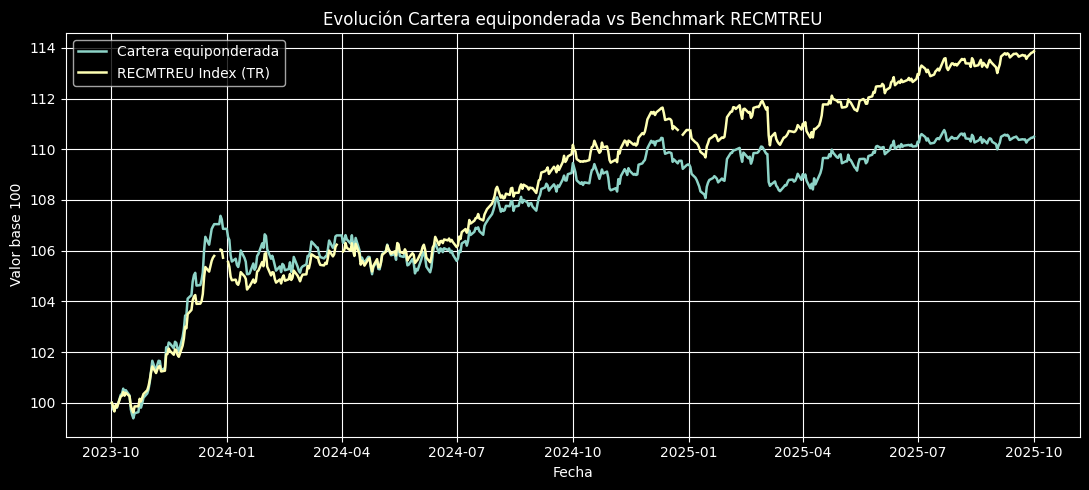

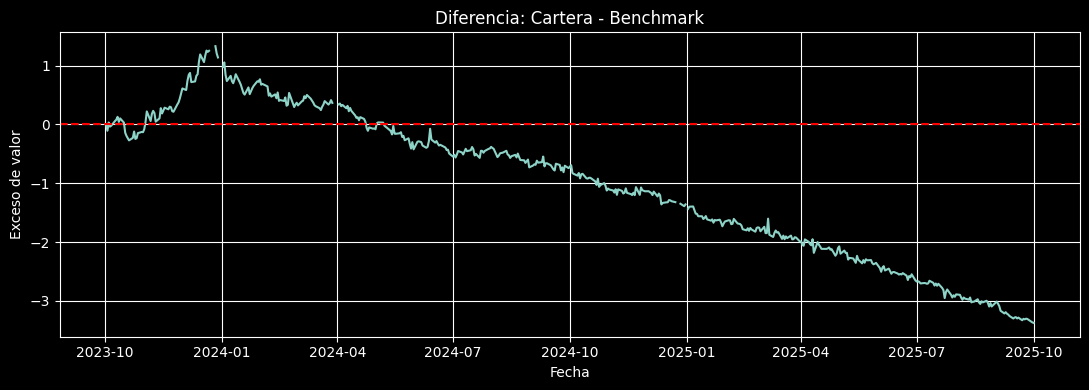

Inicio y final cartera:
2023-10-02    100.000000
2025-10-01    110.497706
dtype: float64

Inicio y final benchmark (en fechas válidas):
2023-10-02    100.000000
2025-10-01    113.870501
Name: RECMTREU Index, dtype: float64

Rentabilidad acumulada cartera:   10.50%
Rentabilidad acumulada benchmark: 13.87%

Proporción de NaNs en benchmark:
0.017208413001912046


In [19]:
import matplotlib.pyplot as plt

# ===============================
# 5. Cartera equiponderada con rebalanceo mensual
# ===============================

panel = precios_universo.copy()
panel = panel.sort_index(axis=1)
fechas = panel.columns

universo_idx = universo.set_index("ISIN")

# ===============================
# 5.1 Fechas de rebalanceo mensuales
# ===============================

fechas_reb = []
ultimo_mes = None

for d in fechas:
    clave_mes = (d.year, d.month)
    if clave_mes != ultimo_mes:
        fechas_reb.append(d)
        ultimo_mes = clave_mes

print("Número de fechas de rebalanceo:", len(fechas_reb))

# ===============================
# 5.2 Backtest cartera equiponderada
# ===============================

valor_cartera = pd.Series(index=fechas, dtype=float)
valor_cartera.iloc[0] = 100.0

pesos_actuales = pd.Series(0.0, index=panel.index)

for i, fecha in enumerate(fechas):
    if fecha in fechas_reb:
        precios_en_fecha = panel[fecha]
        vivos_precio = precios_en_fecha.dropna().index

        bonos_vivos = []
        for isin in vivos_precio:
            if isin in universo_idx.index:
                mat_eff = universo_idx.loc[isin, "Maturity_efectiva"]
                if pd.notna(mat_eff) and mat_eff > fecha:
                    bonos_vivos.append(isin)

        if len(bonos_vivos) > 0:
            pesos_actuales = pd.Series(0.0, index=panel.index)
            pesos_actuales.loc[bonos_vivos] = 1.0 / len(bonos_vivos)

    if i == 0:
        continue

    ret_diaria = (panel[fecha] - panel[fechas[i-1]]) / panel[fechas[i-1]]
    ret_diaria = ret_diaria.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    ret_cartera = (pesos_actuales * ret_diaria).sum()
    valor_cartera.iloc[i] = valor_cartera.iloc[i-1] * (1 + ret_cartera)

# ===============================
# 5.3 Benchmark RECMTREU Index
# ===============================

benchmark = precios_varios["RECMTREU Index"].copy()
benchmark = benchmark.reindex(fechas)

# Buscamos el primer día con dato válido
primer_idx_valido = benchmark.first_valid_index()
primer_valor_valido = benchmark.loc[primer_idx_valido]

# Normalizamos el índice a 100 en ese primer día válido
benchmark_norm = benchmark / primer_valor_valido * 100.0

# ===============================
# 5.4 Gráfico principal
# ===============================

plt.figure(figsize=(11,5))
plt.plot(valor_cartera.index, valor_cartera.values, label="Cartera equiponderada", linewidth=1.8)
plt.plot(benchmark_norm.index, benchmark_norm.values, label="RECMTREU Index (TR)", linewidth=1.8)
plt.title("Evolución Cartera equiponderada vs Benchmark RECMTREU")
plt.xlabel("Fecha")
plt.ylabel("Valor base 100")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ===============================
# 5.5 Gráfico de diferencia
# ===============================

plt.figure(figsize=(11,4))
plt.plot(valor_cartera.index, valor_cartera - benchmark_norm)
plt.axhline(0, color="red", linestyle="--")
plt.title("Diferencia: Cartera - Benchmark")
plt.xlabel("Fecha")
plt.ylabel("Exceso de valor")
plt.grid(True)
plt.tight_layout()
plt.show()

# ===============================
# 5.6 Diagnóstico numérico
# ===============================

print("Inicio y final cartera:")
print(valor_cartera.iloc[[0, -1]])

print("\nInicio y final benchmark (en fechas válidas):")
print(benchmark_norm.loc[[primer_idx_valido, fechas[-1]]])

rent_cartera = valor_cartera.iloc[-1] / valor_cartera.iloc[0] - 1
rent_bench = benchmark_norm.loc[fechas[-1]] / benchmark_norm.loc[primer_idx_valido] - 1

print(f"\nRentabilidad acumulada cartera:   {rent_cartera*100:.2f}%")
print(f"Rentabilidad acumulada benchmark: {rent_bench*100:.2f}%")

print("\nProporción de NaNs en benchmark:")
print(benchmark_norm.isna().mean())


In [20]:
print("¿Hay NaNs en precios de cartera?", valor_cartera.isna().sum())
print("¿Hay NaNs en benchmark?", benchmark_norm.isna().sum())

print("Primera fecha cartera:", valor_cartera.index[0])
print("Primera fecha benchmark:", benchmark_norm.index[0])

print("¿Cartera empieza en 100?", np.isclose(valor_cartera.iloc[0], 100))
print("¿Benchmark empieza en 100?", np.isclose(benchmark_norm.iloc[0], 100))


¿Hay NaNs en precios de cartera? 0
¿Hay NaNs en benchmark? 9
Primera fecha cartera: 2023-10-02 00:00:00
Primera fecha benchmark: 2023-10-02 00:00:00
¿Cartera empieza en 100? True
¿Benchmark empieza en 100? True


### <font color=#336699>6. Cartera mandato</font>

<style>.gray {background-color: #595959}

</style><div class="gray">

❕💬 Como adelantábamos en el enunciado, tienes el mandato de construir una cartera de como máximo **20** bonos corporativos con ese universo y una serie de restricciones y, claro, maximizando la rentabilidad total de la cartera:
- La duración de la cartera no debe superar los 3 años
- La exposición a emisiones HY no puede superar el 10% de la cartera
- No puedes invertir en deuda subordinada
- No se puede invertir en emisiones de tamaño igual o inferior a 500 millones
- No se puede invertir más de un 10% del capital en una misma emisión
- No puede haber más de un 15% de concentración en un mismo emisor
(¡OJO! No estamos teniendo en cuenta en este ejercicio si hubiera un mínimo de inversión, lo cuál sería un dato relevante tener en cuenta en un caso real)

1. Teniendo en cuenta la naturaleza que nos están pidiendo para la cartera, ¿añadirías alguna otra restricción?

2. ¿Cómo medirías el riesgo de crédito de la cartera?

3. ¿Cómo medirías el riesgo de liquidez de la cartera? ¿Se te ocurre alguna otra información que se podría utilizar aunque no se te haya dado?

4. Describe cómo habría que hacer el backtest de esta cartera, no hace falta que lo implementes en este caso

</div>

In [21]:
vivos.columns

Index(['ISIN', 'Description', 'Ccy', 'Price', 'Issuer', 'Industry Sector',
       'Maturity', 'Coupon', 'Rating', 'PD 1YR', 'Outstanding Amount',
       'Callable', 'Next Call Date', 'Seniority', 'Coupon Frequency',
       'Coupon Type', 'First Coupon Date', 'Penultimate Coupon Date',
       'Issue date', 'Bid Price', 'Ask Price', 'Bid-Ask Spread',
       'Maturity_efectiva', 'Precio_modelo_clean', 'Cupon_corrido_pct',
       'Precio_modelo_dirty', 'Z_spread_bps', 'YTM', 'Duration_mod',
       'Convexity', 'T_maturity_anos'],
      dtype='object')

In [22]:
import collections

# ===============================
# 6. Cartera mandato (sobre vivos)
# ===============================

# Definimos ratings IG para separar IG / HY
ig_ratings = ["BBB-", "BBB", "BBB+", "A-", "A", "A+", "AA-", "AA", "AA+", "AAA"]

def construir_cartera_mandato(vivos_df,
                               max_bonos=20,
                               max_duracion=3.0,        # en años
                               max_peso_emision=0.10,
                               max_peso_emisor=0.15,
                               max_peso_hy=0.10):
    """
    Construye una cartera de hasta max_bonos bonos a partir de 'vivos' que cumpla:
    - T_maturity_anos <= max_duracion
    - Peso HY <= max_peso_hy
    - Sin deuda subordinada
    - Outstanding Amount > 500M
    - Peso por emisión <= max_peso_emision
    - Peso por emisor <= max_peso_emisor

    Estrategia: selección greedy de bonos con mejor Z_spread_bps
    (prima de riesgo de crédito), con pesos equiponderados.
    """
    df = vivos_df.copy()

    # Flag HY vs IG (no está en columnas, lo creamos)
    df["is_HY"] = ~df["Rating"].isin(ig_ratings)

    # Filtros estructurales del mandato
    mask_non_sub = ~df["Seniority"].str.contains("Subordinated", case=False, na=False)
    mask_size = df["Outstanding Amount"] > 500e6
    # Usar Duration_mod si está disponible, sino usar T_maturity_anos como fallback
    if "Duration_mod" in df.columns:
        mask_dur = (df["Duration_mod"].notna()) & (df["Duration_mod"] > 0) & (df["Duration_mod"] <= max_duracion)
    else:
        # Fallback a T_maturity_anos si Duration_mod no está disponible
        if "T_maturity_anos" not in df.columns:
            df["T_maturity_anos"] = (df["Maturity_efectiva"] - fecha_valor).dt.days / 365.0
        mask_dur = (df["T_maturity_anos"] > 0) & (df["T_maturity_anos"] <= max_duracion)

    df = df[mask_non_sub & mask_size & mask_dur].copy()

    if df.empty:
        raise ValueError("Tras aplicar filtros de mandato no quedan bonos en 'vivos'.")

    # Usamos directamente el Z_spread_bps que ya tienes
    score_col = "Z_spread_bps"

    df = df.sort_values(score_col, ascending=False).reset_index(drop=True)

    selected_rows = []
    issuer_weights = collections.Counter()
    hy_weight = 0.0

    # Apuntamos a una cartera de max_bonos bonos equiponderados
    target_w = 1.0 / max_bonos

    for _, row in df.iterrows():
        if len(selected_rows) >= max_bonos:
            break

        issuer = row["Issuer"]
        is_hy = bool(row["is_HY"])

        # Peso tentativo si añado este bono
        new_issuer_weight = issuer_weights[issuer] + target_w
        new_hy_weight = hy_weight + (target_w if is_hy else 0.0)

        # Restricciones de mandato por emisor e HY
        if new_issuer_weight > max_peso_emisor + 1e-9:
            continue
        if new_hy_weight > max_peso_hy + 1e-9:
            continue

        # Si pasa los filtros, lo meto en cartera
        selected_rows.append(row)
        issuer_weights[issuer] = new_issuer_weight
        hy_weight = new_hy_weight

    cartera = pd.DataFrame(selected_rows).reset_index(drop=True)
    if len(cartera) == 0:
        raise ValueError("No se ha podido construir ninguna cartera que cumpla las restricciones.")

    # >>> NUEVO: comprobar la restricción de peso máximo por emisión
    peso_eq = 1.0 / len(cartera)
    if peso_eq > max_peso_emision + 1e-9:
        raise ValueError(
            f"La cartera resultante sólo tiene {len(cartera)} bonos, "
            f"lo que implica un peso equiponderado de {peso_eq:.1%} "
            f"> {max_peso_emision:.0%} máximo permitido por emisión."
        )
    # <<<

    # Peso equiponderado final (sabemos que respeta el 10% por emisión)
    cartera["weight"] = peso_eq

    # Métricas de comprobación: usar Duration_mod (duración modificada real)
    if "Duration_mod" in cartera.columns:
        # Calcular duración de la cartera usando Duration_mod
        duracion_cartera = (cartera["Duration_mod"] * cartera["weight"]).fillna(0).sum()
        # Verificar que cumple la restricción de duración
        if duracion_cartera > max_duracion + 1e-6:
            print(f"⚠️ ADVERTENCIA: La duración de la cartera ({duracion_cartera:.2f} años) excede el límite de {max_duracion} años.")
    else:
        # Fallback a T_maturity_anos si Duration_mod no está disponible
        if "T_maturity_anos" not in cartera.columns:
            cartera["T_maturity_anos"] = (cartera["Maturity_efectiva"] - fecha_valor).dt.days / 365.0
        duracion_cartera = (cartera["T_maturity_anos"] * cartera["weight"]).sum()
        print("⚠️ ADVERTENCIA: Usando T_maturity_anos como proxy de duración (Duration_mod no disponible)")
    
    peso_hy_cartera = cartera.loc[cartera["is_HY"], "weight"].sum()
    conc_emisor = cartera.groupby("Issuer")["weight"].sum().max()

    print("Número de bonos en cartera:", len(cartera))
    print(f"Duración modificada de la cartera: {duracion_cartera:.2f} años")
    print(f"Peso en HY: {peso_hy_cartera:.1%}")
    print(f"Máxima concentración por emisor: {conc_emisor:.1%}")
    print(f"Peso por emisión (equiponderado): {peso_eq:.1%}")

    return cartera

# Construimos la cartera mandato usando el fichero 'vivos'
cartera_mandato = construir_cartera_mandato(vivos)

display(cartera_mandato[[
    "ISIN", "Issuer", "Industry Sector", "Rating",
    "Maturity_efectiva", "T_maturity_anos", "Outstanding Amount",
    "is_HY", "weight"
]])


Número de bonos en cartera: 20
Duración modificada de la cartera: 1.77 años
Peso en HY: 10.0%
Máxima concentración por emisor: 15.0%
Peso por emisión (equiponderado): 5.0%


,ISIN,Issuer,Industry Sector,Rating,Maturity_efectiva,T_maturity_anos,Outstanding Amount,is_HY,weight
0,FR001400KXW4,RCI BANQUE SA,"Consumer, Cyclical",BBB,2026-07-02,0.750685,750000000,False,0.05
1,FR001400J861,TDF INFRASTRUCTURE SAS,Communications,NR,2028-04-21,2.556164,600000000,True,0.05
2,FR0013231768,IMERYS SA,Industrial,BBB-,2026-10-15,1.038356,600000000,False,0.05
3,XS2724457457,FORD MOTOR CREDIT CO LLC,"Consumer, Cyclical",BB+,2029-02-20,3.391781,750000000,True,0.05
4,FR001400H2O3,RCI BANQUE SA,"Consumer, Cyclical",BBB,2027-01-06,1.265753,750000000,False,0.05
5,FR001400IEQ0,RCI BANQUE SA,"Consumer, Cyclical",BBB,2028-03-14,2.452055,750000000,False,0.05
6,XS2225207468,HEIMSTADEN BOSTAD TRESRY,Financial,BBB-,2026-12-03,1.172603,700000000,False,0.05
7,XS2356040357,STELLANTIS NV,"Consumer, Cyclical",BBB,2028-10-18,3.049315,1250000000,False,0.05
8,XS1492458044,UTAH ACQUISITION SUB,"Consumer, Non-cyclical",BBB-,2028-08-22,2.893151,750000000,False,0.05
9,XS2397252102,HEIMSTADEN BOSTAD TRESRY,Financial,BBB-,2028-01-13,2.284932,750000000,False,0.05


##### <font color=#CC6600>Riesgo de crédito</font>

In [23]:
# ===============================
# Riesgo de crédito de la cartera mandato
# ===============================

if "cartera_mandato" not in globals():
    raise RuntimeError("Primero ejecuta la celda de construcción de la cartera (cartera_mandato).")

cartera_credito = cartera_mandato.copy()

# PD ponderada a 1 año
pd_ponderada = (cartera_credito["PD 1YR"] * cartera_credito["weight"]).sum()

# Distribución de pesos por rating
dist_rating = (
    cartera_credito
    .groupby("Rating")["weight"]
    .sum()
    .sort_values(ascending=False)
)

# Peso en HY (columna is_HY viene de la construcción de la cartera)
peso_hy = cartera_credito.loc[cartera_credito["is_HY"], "weight"].sum()

print(f"PD 1 año ponderada de la cartera: {pd_ponderada:.2%}")
print(f"Peso en HY: {peso_hy:.1%}\n")

print("Distribución de peso por rating:")
display(dist_rating.to_frame(name="weight"))

# Z-spread medio usando directamente 'Z_spread_bps'
z_spread_medio = (cartera_credito["Z_spread_bps"] * cartera_credito["weight"]).sum()
print(f"\nZ-spread plano medio ponderado: {z_spread_medio:.1f} bps")


PD 1 año ponderada de la cartera: 0.97%
Peso en HY: 10.0%

Distribución de peso por rating:


,weight
Rating,
BBB-,0.60
BBB,0.25
BB+,0.05
BBB+,0.05
NR,0.05



Z-spread plano medio ponderado: 136.0 bps


La PD 1Y ponderada te da una idea de la probabilidad de impago a un año de la cartera como un todo.

La distribución por rating te dice cuánto peso llevas en BBB, A, etc.

El peso en HY confirma que cumples el límite del 10%.

El Z-spread medio (si lo tienes) es una métrica sencilla de “prima de riesgo de crédito” exigida por el mercado.

##### <font color=#CC6600>Riesgo de liquidez</font>

In [24]:
# ===============================
# Riesgo de liquidez de la cartera mandato
# ===============================

if "cartera_mandato" not in globals():
    raise RuntimeError("Primero ejecuta la celda de construcción de la cartera (cartera_mandato).")

cartera_liquidez = cartera_mandato.copy()

# Usamos directamente la columna 'Bid-Ask Spread' que ya tienes en vivos
# (suponemos que está en bps o en la unidad que haya definido el enunciado)
cartera_liquidez["bid_ask_bps"] = cartera_liquidez["Bid-Ask Spread"]

# Tamaño de emisión en millones de euros
cartera_liquidez["Outstanding_MEUR"] = cartera_liquidez["Outstanding Amount"] / 1e6

bid_ask_medio = (cartera_liquidez["bid_ask_bps"] * cartera_liquidez["weight"]).sum()
tam_medio = (cartera_liquidez["Outstanding_MEUR"] * cartera_liquidez["weight"]).sum()

# Porcentaje invertido en emisiones "pequeñas" dentro del universo elegible (por ejemplo < 750M)
peso_small = cartera_liquidez.loc[
    cartera_liquidez["Outstanding Amount"] < 750e6, "weight"
].sum()

print(f"Bid-ask medio ponderado: {bid_ask_medio:.1f}")
print(f"Tamaño medio de emisión ponderado: {tam_medio:.1f} M€")
print(f"Peso en emisiones < 750M: {peso_small:.1%}\n")

print("Top 5 bonos más ilíquidos por bid-ask:")
display(
    cartera_liquidez[["ISIN", "Issuer", "Rating", "Outstanding_MEUR", "bid_ask_bps", "weight"]]
    .sort_values("bid_ask_bps", ascending=False)
    .head(5)
)


Bid-ask medio ponderado: 0.3
Tamaño medio de emisión ponderado: 745.0 M€
Peso en emisiones < 750M: 35.0%

Top 5 bonos más ilíquidos por bid-ask:


,ISIN,Issuer,Rating,Outstanding_MEUR,bid_ask_bps,weight
11,XS2489775580,SES SA,BBB-,750.0,0.589,0.05
18,XS1734066811,PVH CORP,BBB-,600.0,0.362,0.05
1,FR001400J861,TDF INFRASTRUCTURE SAS,NR,600.0,0.342,0.05
3,XS2724457457,FORD MOTOR CREDIT CO LLC,BB+,750.0,0.330,0.05
7,XS2356040357,STELLANTIS NV,BBB,1250.0,0.306,0.05


##### <font color=#CC6600>Backtest</font>

In [25]:
# ===============================
# Backtest de la cartera mandato (solo esquema)
# ===============================
#
# Idea de cómo se haría el backtest paso a paso:
#
# 1. Fijar la fecha inicial y final del histórico de precios (precios_universo)
#    y la frecuencia de rebalanceo (por ejemplo mensual, como en la cartera equiponderada).
#
# 2. En cada fecha de rebalanceo:
#    - Aplicar el mismo algoritmo de selección del mandato
#      sobre el universo en esa fecha (filtrando vencidos, HY, tamaños, etc.).
#    - Obtener la lista de ISIN y los pesos target en esa fecha.
#
# 3. Entre dos fechas de rebalanceo:
#    - Mantener los pesos constantes.
#    - Calcular el valor diario de la cartera como:
#        V_t = sum_i (peso_i * precio_i_t)
#      normalizado a un capital inicial (por ejemplo 100 o 10 millones).
#
# 4. Encadenar los rendimientos diarios para obtener:
#    - Rentabilidad acumulada.
#    - Volatilidad anualizada, drawdown máximo, etc.
#
# 5. Comparar contra un benchmark (por ejemplo RECMTREU Index):
#    - Normalizar el índice al mismo valor inicial
#      y trazar ambos (cartera vs benchmark).
#
# 6. Analizar:
#    - Cómo se comporta la cartera en shocks de tipos / crédito.
#    - Si el mandato impone un “coste” en rentabilidad frente al benchmark.
#


### <font color=#336699>7. Cobertura tipos de interés</font>

<style>.gray {background-color: #595959}

</style><div class="gray">

❕💬 Utiliza alguno de los siguientes instrumentos de los que te hemos dado para cubrir la duración (sensibilidad de tipos de interés) de la cartera que has construido según el mandato. Asume una inversión en la cartera de 10 millones:

- Futuros sobre el *Schatz* (ticker: DU1) - Duración a 01/10/2025: 1.92
- Futuros sobre el *BOBL* (ticker: OE1) - Duración a 01/10/2025: 5.44
- Futuros sobre el *BUND* (ticker: RX1) - Duración a 01/10/2025: 10

*Contract size* en todos los casos: 100,000 euros

Investiga sobre estos instrumentos antes de tomar la decisión. Razona tu elección del instrumento y el número de contratos que has decidido comprar/vender.

- ¿Qué pasaría si comprásemos/vendiésemos 100 futuros?
- ¿Se te ocurre algún otro instrumento con el que cubrir la sensibilidad a los tipos de interés de la cartera?

</div>

In [26]:
# NO PROGRAMAR

Partimos de una inversión de **10 millones de euros** en la cartera de mandato.  
La duración media aproximada de la cartera es:

$$
D_{\text{cartera}} \approx 2.08 \text{ años}
$$

La sensibilidad de la cartera a un movimiento paralelo de tipos de **1 pb**
(en términos de DV01) es aproximadamente:

$$
\text{DV01}_{\text{cartera}} 
= D_{\text{cartera}} \times \text{MV} \times 0.0001
$$

$$
= 2.08 \times 10{,}000{,}000 \times 0.0001 
\approx 2{,}080 \,€/\text{pb}
$$

Si tomamos el futuro sobre el **Schatz (DU1)**, cuya duración aproximada es **1.92 años**
y su precio el 01/10/2025 es **106.995**, con contract size **100,000 €**:

$$
PV_{\text{futuro}} 
= 106.995\% \times 100{,}000
\approx 106{,}995 \,€
$$

$$
DV01_{\text{DU1}} 
= 1.92 \times 106{,}995 \times 0.0001
\approx 20.5 \,€/\text{pb}
$$

El número de contratos necesarios para neutralizar la sensibilidad de tipos:

$$
N = \frac{2{,}080}{20.5} \approx 101
$$

Como estamos **largos** de bonos, para cubrirnos frente a una **subida de tipos**
(vía caída de precios) debemos tomar una **posición corta** en futuros:

**→ vender ~101 contratos de Schatz.**

Si en lugar de 101 empleásemos, por ejemplo, **100 contratos**, la DV01 residual sería:

$$
DV01_{\text{residual}}
= 2{,}080 - 100 \times 20.5
\approx 26 \,€/\text{pb}
$$

La cartera quedaría casi neutralizada en tipos, aunque con algo de basis risk.

El Schatz es un buen candidato porque su duración (**1.92 años**) está alineada con la duración media de la cartera (**≈2 años**).  
Alternativamente se podrían usar **BOBL (5.44 años)** o **BUND (10 años)**, que requieren menos contratos pero introducen mayor descalce de duración.


### <font color=#336699>8. Cobertura crédito</font>

<style>.gray {background-color: #595959}

</style><div class="gray">

❕💬 Utiliza alguno de los siguientes instrumentos de los que te hemos dado para cubrir el riesgo de crédito de la cartera que has construido según el mandato. Asume una inversión en la cartera de 10 millones:

- ITRAXX Main (ticker: ITRX EUR CDSI GEN 5Y Corp)
- ITRAXX XOVER (ticker: ITRX XOVER CDSI GEN 5Y Corp)

Estos índices cotizan en forma de spread, en puntos básicos. La sensibilidad del valor del swap (CDS) la vamos a asumir en 4,500€ al punto básico asumiendo una inversión de 10 millones.

Investiga sobre estos instrumentos antes de tomar la decisión. Razona tu elección del instrumento y el nominal que has decidido comprar/vender.

- ¿Tiene sentido plantear esta cobertura total?
- ¿Con qué otros instrumentos podrías cubrir el riesgo de crédito?

</div>

In [27]:
# NO PROGRAMAR

La cartera de mandato está compuesta mayoritariamente por bonos **investment grade**
(con peso en HY ≈ 10%). Una forma estándar de cubrir el riesgo de crédito sistemático
es utilizar índices de CDS como:

- **iTraxx Main** (ITRX EUR CDSI GEN 5Y Corp) – representa crédito IG europeo.
- **iTraxx XOVER** (ITRX XOVER CDSI GEN 5Y Corp) – representa crédito high yield.

Como la mayor parte del riesgo de crédito de la cartera es IG, lo más natural sería
usar **iTraxx Main** para cubrir el riesgo sistemático de spread. Conceptualmente:

- Si estoy **largo de crédito** (largo de bonos corporativos), para cubrirme
  necesito estar **largo de protección** en el índice (comprar protección / pagar prima),
  lo que equivale a una posición corta en riesgo de crédito.

El enunciado indica que la **sensibilidad del índice** es de unos **4.500 €/pb
para una inversión de 10 millones**. Si denotamos:

- \( \text{DV01}_{\text{cartera, crédito}} \): sensibilidad de la cartera a 1 pb de widening de spreads  
- \( \text{DV01}_{\text{índice}} \): sensibilidad del índice para 10M (≈ 4,500 €/pb)

el nocional \( N \) del índice necesario para cubrir una fracción \( \alpha \) del riesgo sería:

$$
N \approx \alpha \times 10\,\text{M} \times 
\frac{\text{DV01}_{\text{cartera, crédito}}}{\text{DV01}_{\text{índice}}}
$$

En la práctica, como no tenemos aquí la duración de spread exacta, una aproximación razonable sería:

- Estimar la **parte IG** de la cartera (≈ 90% del nominal).  
- Cubrir, por ejemplo, **entre el 50% y el 100%** de ese riesgo con iTraxx Main.

Cubrir el **100%** del riesgo de crédito tendría el efecto de **eliminar casi toda la prima
de spread** que estamos intentando capturar con la cartera, por lo que típicamente se optaría
por una **cobertura parcial** (por ejemplo 50–70%), manteniendo cierta exposición direccional
a los spreads.

Si quisiéramos cubrir específicamente la parte HY (≈10% de la cartera), tendría más sentido
utilizar **iTraxx XOVER**, que está diseñado precisamente para crédito high yield.  
También se podría plantear una cobertura combinada:

- Corto riesgo con iTraxx Main por la parte IG.  
- Corto riesgo con iTraxx XOVER por la parte HY.

Otros instrumentos alternativos que se podrían considerar:

- **CDS single name** sobre emisores concretos con mayor riesgo.  
- **Bonos soberanos / swaps de tipos** si se quiere aislar parte del componente de tipos
  y dejar sólo riesgo de crédito relativo.


### <font color=#336699>9. Estrategia propia</font>

<style>.gray {background-color: #595959}

</style><div class="gray">

❕💬 Plantea tu propia estrategia con la información que tienes. Puede ser una estrategia direccional, de valor relativo, que hayas visto o no en clase; pero siempre razonando tu planteamiento.

</div>

In [28]:
# NO PROGRAMAR

Como estrategia propia, propondría una **cartera factor credit spread – calidad – liquidez**
con las siguientes reglas:

1. **Universo de partida**
   - Mismo universo de bonos corporativos EUR.
   - Se excluyen desde el inicio:
     - Emisiones subordinadas.
     - Emisiones con Outstanding Amount ≤ 500M.
     - Bonos sin precio BID/ASK.

2. **Filtros de riesgo / mandato**
   - Duración objetivo de la cartera entre **2 y 4 años**.
   - Límite de **peso HY** del 15%.
   - Límite de **10% por emisión** y **15% por emisor**, igual que en el mandato.

3. **Señales de selección**
   - Dentro del universo filtrado, se calcula para cada bono:
     - Su **Z-spread plano**.
     - Su **rating** y PD 1Y.
     - Su **bid-ask spread**.
   - Se construye un **score compuesto**:

$$
\text{score}_i 
= \text{Zspread}_i
- \lambda_1 \cdot \text{PD}_{1Y,i}
- \lambda_2 \cdot \text{bid\_ask}_i
$$

   donde:
   - Z-spread alto es positivo (más prima de riesgo),
   - PD alta penaliza,
   - bid-ask alto penaliza (menor liquidez).

4. **Construcción de cartera**
   - Se ordenan los bonos por el score de mayor a menor.
   - Se seleccionan, por ejemplo, **40 bonos**:
     - 30 bonos IG (con mejor score dentro de IG),
     - 10 bonos HY (mejor score dentro de HY pero respetando límites de peso).
   - Se asignan pesos **equiponderados** dentro de cada bucket:
     - IG: 80% de la cartera (≈ 2% por bono).
     - HY: 20% de la cartera (≈ 2% por bono).
   - Se fuerza una **diversificación sectorial** básica:
     - Máx. 25% por sector.

5. **Rebalanceo**
   - **Mensual**, coincidiendo con las fechas de rebalanceo del histórico.
   - En cada rebalanceo:
     - Se recalculan scores con spreads, ratings y liquidez actualizados.
     - Se reconstruye la cartera aplicando las mismas reglas.

6. **Razonamiento**
   - La estrategia intenta capturar:
     - **Prima de spread** (Z-spread alto),
     - Controlando la **calidad crediticia** (PD, rating),
     - Y penalizando la **iliquidez** (bid-ask).
   - El bucket HY aporta algo de carry adicional, pero con límites claros.
   - El rebalanceo mensual permite actualizar la selección según cambios de spreads,
     sin generar un exceso de trading.

Esta estrategia se podría backtestear igual que la cartera equiponderada,
pero usando estas reglas para seleccionar pesos en cada fecha de rebalanceo
y comparando contra un benchmark como **RECMTREU**.
